In [1]:
%cd plot/

[Errno 2] No such file or directory: 'plot/'
/opt/hpcaas/.mounts/fs-0df31b178aa4037ac/home/zhaobc/scientist/plot


/home/zhaobc/miniconda3/envs/nanogpt-record-1-11/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info, compute_gap_in_percentage_list_keep_name
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [3]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [ ]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         '/checkpoint/maui/zhaobc/scientist/workspace/0511_relaunch/record_*',
#         '/checkpoint/maui/zhaobc/scientist/workspace/0507_relaunch/record_*',
#         '/checkpoint/maui/zhaobc/scientist/workspace/r1_relaunch/record_*'
#     ]
# )

Found 3624 directories


  0%|          | 1/3624 [00:00<06:12,  9.74it/s]

100%|██████████| 3624/3624 [11:08<00:00,  5.42it/s]


In [5]:
# with open('may13.cache', 'w') as f:
#     json.dump(ori_results, f)

In [6]:
# with open('may8.cache', 'r') as f:
#     ori_results = json.load(f)
with open('may13.cache', 'r') as f:
    ori_results = json.load(f)

In [7]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [8]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [9]:
folder_info = ori_results
# o3_results

In [10]:
len(folder_info)

3592

In [11]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 20
flat z o3-mini 60
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 2 deepseek-r1 20
flat 2 o3-mini 60
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 125 deepseek-r1 75
flat 125 o3-mini 55
tree z deepseek-r1 20
tree z o3-mini 60
tree 1 deepseek-r1 18
tree 1 o3-mini 106
tree 2 deepseek-r1 20
tree 2 o3-mini 60
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 125 deepseek-r1 75
tree 125 o3-mini 74
forest z deepseek-r1 20
forest z o3-mini 60
forest 1 deepseek-r1 18
forest 1 o3-mini 106
forest 2 deepseek-r1 20
forest 2 o3-mini 60
forest 5 deepseek-r1 60
forest 5 o3-mini 60
forest 12 deepseek-r1 55
forest 12 o3-mini 64
forest 125 deepseek-r1 90
forest 125 o3-mini 70
ori_aide z deepseek-r1 20
ori_aide z o3-mini 60
ori_aide 1 deepseek-r1 15
ori_aide 1 o3-mini 106
ori_aide 2 deepseek-r1 20
ori_aide 2 o3-mini 60
ori_aide 5 deepseek-r1 57
ori_aide 5 o3-mini 57
ori_aide 12 deepseek-r1 54
ori_aide 12 o3-m

In [12]:
from tqdm import tqdm

figure_data = {}
for search_algo in search_algo_params.keys():
    for level in ['z', 1, 2, 5, 12, 125]:
        # for model in ['o3-mini']:
        for model in ['deepseek-r1', 'o3-mini']:
            plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
            # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)


In [13]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [14]:
figure_data_percent = {}
for key in figure_data.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_z_deepseek-r1
flat_z_o3-mini
flat_1_deepseek-r1
flat_1_o3-mini
flat_2_deepseek-r1
flat_2_o3-mini
flat_5_deepseek-r1
flat_5_o3-mini
flat_12_deepseek-r1
flat_12_o3-mini
flat_125_deepseek-r1
flat_125_o3-mini
tree_z_deepseek-r1
tree_z_o3-mini
tree_1_deepseek-r1
tree_1_o3-mini
tree_2_deepseek-r1
tree_2_o3-mini
tree_5_deepseek-r1
tree_5_o3-mini
tree_12_deepseek-r1
tree_12_o3-mini
tree_125_deepseek-r1
tree_125_o3-mini
forest_z_deepseek-r1
forest_z_o3-mini
forest_1_deepseek-r1
forest_1_o3-mini
forest_2_deepseek-r1
forest_2_o3-mini
forest_5_deepseek-r1
forest_5_o3-mini
forest_12_deepseek-r1
forest_12_o3-mini
forest_125_deepseek-r1
forest_125_o3-mini
ori_aide_z_deepseek-r1
ori_aide_z_o3-mini
ori_aide_1_deepseek-r1
ori_aide_1_o3-mini
ori_aide_2_deepseek-r1
ori_aide_2_o3-mini
ori_aide_5_deepseek-r1
ori_aide_5_o3-mini
ori_aide_12_deepseek-r1
ori_aide_12_o3-mini
ori_aide_125_deepseek-r1
ori_aide_125_o3-mini
multi_aide_z_deepseek-r1
multi_aide_z_o3-mini
multi_aide_1_deepseek-r1
multi_aide_1_o3-m

In [15]:
# Get top 3 values for each experiment, padding if needed
def get_top_3_values(arr, config=None, exp_name=None):
    if len(arr) == 0:
        return np.array([0, 0, 0])
    # Filter out values > 3 or < 0
    valid_arr = []
    for x in arr:
        if not (0 <= x <= 3):
            print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
            valid_arr.append(0)
        else:
            valid_arr.append(x)
    sorted_arr = np.sort(valid_arr)[::-1] # Sort descending
    if len(arr) >= 3:
        return sorted_arr[:3]
    else:
        # Pad with repeats of max value to get 3 numbers
        padding = 3 - len(arr)
        if not ('r1' in config):
            # Only log warning once per config
            if exp_name == list(figure_data_percent[config].keys())[0]:
                print(f"Warning: Config {config} has experiments with fewer than 3 values, padding with {padding} repeated values")
        return np.concatenate([sorted_arr, np.repeat(sorted_arr[-1], padding)])

# Process each config
results_by_config = {}
for config, experiments in figure_data_percent.items():
    # Get top 3 values for each experiment
    top3_by_experiment = {}
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
    for exp_name, values in experiments.items():
        top3 = get_top_3_values(values, config, exp_name)
        top3_by_experiment[exp_name] = top3
    
    # Average across experiments for each of the 3 positions
    all_exp_values = np.array(list(top3_by_experiment.values()))
    mean_values = np.mean(all_exp_values, axis=0) # Shape (3,)
    
    # Calculate standard error of the mean (SEM) instead of std
    n = len(all_exp_values) if len(all_exp_values) > 0 else 1
    sem_value = np.std(mean_values) / np.sqrt(n)
    
    results_by_config[config] = {
        'means': np.mean(mean_values) if len(all_exp_values) > 0 else 0,
        'std': sem_value if len(all_exp_values) > 0 else 0  # Using 'std' key for compatibility but storing SEM
    }


In [16]:
results_by_config['ori_aide_1_deepseek-r1']

{'means': 0.17269570584189253, 'std': 0.0}

In [17]:
top3_by_experiment.keys()

dict_keys(['8', '14', '18', '13', '4', '19', '11', '2', '7', '17', '10', '3', '12', '1', '15', '5', '16', '9'])

In [18]:
import matplotlib as mpl

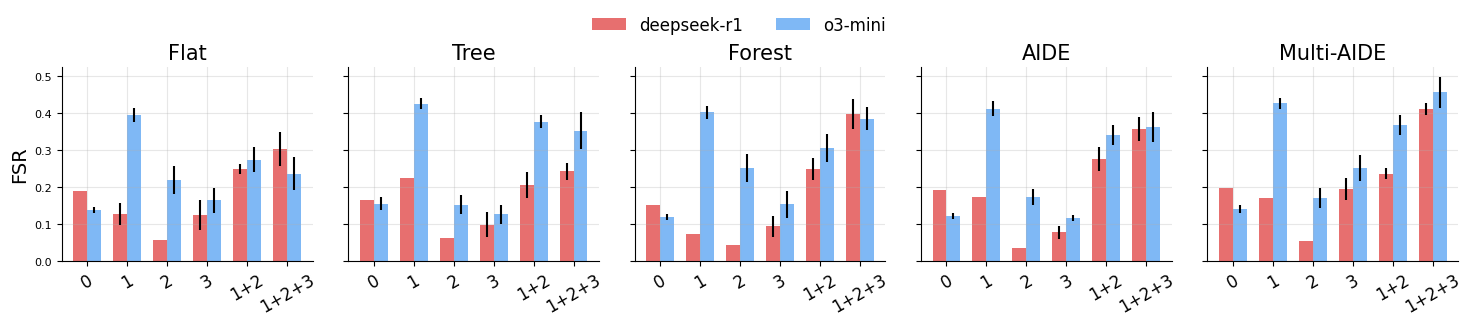

In [19]:
# colors = ['magma', 'plasma']
# colors = ['crimson', 'royalblue']
colors = ['#E76F6F', '#7FB8F5']
# colors = [plt.cm.get_cmap('plasma')(level) for level in [0.3, 0.9]]
# x_labels = ['z', 1, 2, 5, 12, 125]
x_labels = [0, 1, 2, 3, '1+2', '1+2+3']
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    for i, model in enumerate(['deepseek-r1', 'o3-mini']):
        y = []
        err = []
        for level in ['z', 1, 2, 5, 12, 125]:
            key = f'{search_algo}_{level}_{model}'
            if key in results_by_config:
                y.append(results_by_config[key]['means'])
                err.append(results_by_config[key]['std'])
            else:
                y.append(0)
                err.append(0)
        axes[idx].bar(x_values - w/2 + i * w, y, width=w, color=colors[i], label=model if idx == 0 else "", yerr=err)
    
    axes[idx].set_title(['Flat', 'Tree', 'Forest', 'AIDE', 'Multi-AIDE'][idx], fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=12, rotation=30)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].set_ylabel('FSR', fontsize=14)

# shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
# plt.show()
plt.savefig('figures/fsr_across_hint_levels.pdf', dpi=200, bbox_inches='tight')

In [143]:
results_by_config

{'flat_z_deepseek-r1': {'means': 0.1881468717025764,
  'std': 6.542051911182397e-18},
 'flat_z_o3-mini': {'means': 0.13698466331052392, 'std': 0.008183831410467074},
 'flat_1_deepseek-r1': {'means': 0.12657664606094157,
  'std': 0.03055438595305219},
 'flat_1_o3-mini': {'means': 0.39631873684661484, 'std': 0.018780829307960403},
 'flat_2_deepseek-r1': {'means': 0.05584850965701866, 'std': 0.0},
 'flat_2_o3-mini': {'means': 0.21988471956540157, 'std': 0.038265234199133885},
 'flat_5_deepseek-r1': {'means': 0.12532532235682997,
  'std': 0.0405445142885524},
 'flat_5_o3-mini': {'means': 0.16462045545135606, 'std': 0.033833789679087796},
 'flat_12_deepseek-r1': {'means': 0.24838174352852904,
  'std': 0.013135107563934911},
 'flat_12_o3-mini': {'means': 0.27365352659721387, 'std': 0.03415358493866545},
 'flat_125_deepseek-r1': {'means': 0.30306130644968526,
  'std': 0.044777678031007635},
 'flat_125_o3-mini': {'means': 0.2364127923638016,
  'std': 0.044738941178733595},
 'tree_z_deepseek-r1

In [20]:
from parse_levels import process_metrics_raw_path, list_of_base_paths


In [21]:
r1_codes_dist = pd.read_csv('/checkpoint/maui/zhaobc/scientist/may11_r1_code.csv')
o3_codes_dist = pd.read_csv('/checkpoint/maui/zhaobc/scientist/may11_o3_code.csv')

In [22]:
o3_codes_dist = pd.concat([r1_codes_dist, o3_codes_dist])

In [23]:
o3_codes_dist['run_id'].unique().shape

(2310,)

In [24]:
norm_o3_codes_dist = o3_codes_dist.copy()
norm_o3_codes_dist['norm_cos_start'] = norm_o3_codes_dist['cos_start'] / norm_o3_codes_dist['human_cos'] 
norm_o3_codes_dist['norm_cos_end'] = norm_o3_codes_dist['cos_end'] / norm_o3_codes_dist['human_cos']
norm_o3_codes_dist['norm_l2_start'] = norm_o3_codes_dist['l2_start'] / norm_o3_codes_dist['human_l2']
norm_o3_codes_dist['norm_l2_end'] = norm_o3_codes_dist['l2_end'] / norm_o3_codes_dist['human_l2']

In [25]:
# norm_o3_codes_dist.head()

In [26]:
min_train_time_list = []
for idx, row in tqdm(norm_o3_codes_dist.iterrows(), total=len(norm_o3_codes_dist)):
    for base_path in list_of_base_paths:
        run_folder = os.path.join(base_path, row['run_id'])
        if os.path.exists(run_folder):
            break
    metrics = process_metrics_raw_path(run_folder, row['record'])
    min_train_time = metrics['train_time'].min()
    min_train_time_list.append(min_train_time)

100%|██████████| 2310/2310 [00:56<00:00, 40.65it/s]


In [27]:
norm_o3_codes_dist['min_train_time'] = min_train_time_list
# norm_o3_codes_dist.head()

In [28]:
gap_list = []
model_gap_list = []
for idx, row in tqdm(norm_o3_codes_dist.iterrows(), total=len(norm_o3_codes_dist)):
    record_num = row['record']
    human_time = human_train_time_dict[record_num]
    gap = human_time - human_train_time_dict[record_num+1]
    # model_gap = row['min_train_time'] - human_train_time_dict[record_num+1]
    model_gap = human_time - row['min_train_time']
    gap_list.append(gap)
    model_gap_list.append(model_gap)
norm_o3_codes_dist['gap'] = gap_list
norm_o3_codes_dist['model_gap'] = model_gap_list
# norm_o3_codes_dist.head()



100%|██████████| 2310/2310 [00:00<00:00, 45076.12it/s]


In [29]:
norm_o3_codes_dist['reproduced'] = norm_o3_codes_dist['model_gap'] / norm_o3_codes_dist['gap']
norm_o3_codes_dist.head()


# why so many 1?



,method,model,record,levels,run_id,cos_start,cos_end,l2_start,l2_end,human_cos,human_l2,norm_cos_start,norm_cos_end,norm_l2_start,norm_l2_end,min_train_time,gap,model_gap,reproduced
0,tree,deepseek-r1,12,z,record_12_20250504_141041_2200393-2200331-1,-1.192093e-07,0.006341,0.0,17.101551,0.006341,17.101551,-0.000019,1.0,0.0,1.0,312612.0,28034,5227.0,0.186452
1,tree,deepseek-r1,8,z,record_8_20250504_161022_2201339-2200955-7,1.192093e-07,0.011043,0.0,22.534748,0.011043,22.534748,0.000011,1.0,0.0,1.0,662205.0,156674,0.0,0.000000
2,tree,deepseek-r1,19,z,record_19_20250504_181030_2202128-2201681-0,-1.192093e-07,0.039306,0.0,43.281780,0.039306,43.281780,-0.000003,1.0,0.0,1.0,198981.0,10762,461.0,0.042836
3,tree,deepseek-r1,9,z,record_9_20250504_161022_2201340-2200955-8,1.192093e-07,0.007622,0.0,18.767290,0.007622,18.767290,0.000016,1.0,0.0,1.0,505531.0,28381,0.0,0.000000
4,tree,deepseek-r1,10,z,record_10_20250504_161022_2200955-2200955-9,0.000000e+00,0.008124,0.0,19.370594,0.008124,19.370594,0.000000,1.0,0.0,1.0,477150.0,34165,0.0,0.000000


In [30]:
norm_o3_codes_dist.loc[norm_o3_codes_dist['reproduced'] > 1.5, 'reproduced'] = 0
norm_o3_codes_dist.loc[norm_o3_codes_dist['reproduced'] < 0, 'reproduced'] = 0

In [31]:
norm_o3_codes_dist.loc[norm_o3_codes_dist['norm_l2_end'] > 4, 'norm_l2_end'] = 1.0
norm_o3_codes_dist.loc[norm_o3_codes_dist['norm_l2_end'] < 0.1, 'norm_l2_end'] = 1.0

In [32]:
from matplotlib.legend_handler import HandlerTuple

In [114]:
# # Get unique methods and models
# methods = norm_o3_codes_dist['method'].unique()
# models = norm_o3_codes_dist['model'].unique()

# # Define markers for methods
# markers = {
#     'flat': 'o',      # circle
#     'forest': 's',    # square 
#     'multi_aide': '^',  # triangle up
#     'ori_aide': 'v',    # triangle down
#     'tree': 'D'         # diamond
# }

# # Define colormaps for models
# model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# # Define level darkness scale (0 to 1)
# level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

# fig, ax = plt.subplots(figsize=(15, 8))

# # Plot points
# for method in methods:
#     for model in models:
#         for level in ['z', '1', '2', '5', '12', '125']:
#             mask = (norm_o3_codes_dist['method'] == method) & \
#                    (norm_o3_codes_dist['model'] == model) & \
#                    (norm_o3_codes_dist['levels'] == level)
            
#             if mask.any():
#                 cmap = model_cmaps[model]
#                 color = cmap(level_darkness[level])
#                 ax.scatter(norm_o3_codes_dist[mask]['reproduced'], 
#                          norm_o3_codes_dist[mask]['norm_l2_end'],
#                          marker=markers[method],
#                          c=[color],
#                          alpha=0.7)

# ax.set_xlabel('Reproduced', fontsize=12)
# ax.set_ylabel('L2 End', fontsize=12)
# # ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# ax.grid(True, alpha=0.3)
# ax.invert_yaxis()

# # Create legend for methods
# method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
#                            label=method, markersize=10, linestyle='None')
#                  for method in methods]

# # Create legend for models and levels 
# model_patches = []
# for model in models:
#     cmap = model_cmaps[model]
#     model_patches.append(
#         plt.Line2D([0], [0], marker='s', color=cmap(0.5),
#                    label=model, markersize=10, linestyle='None')
#     )

# level_patches = []
# level_labels = []
# for level in ['z', '1', '2', '5', '12', '125']:
#     label = f'L{level}' if level != 'z' else 'zero knowledge'
#     color1 = model_cmaps['o3-mini'](level_darkness[level])
#     color2 = model_cmaps['deepseek-r1'](level_darkness[level])

#     marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
#     marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
#     level_patches.append((marker_1, marker_2))
#     level_labels.append(label)
#     # level_patches.append(
#     #     plt.Line2D([0], [0], marker='o', color=color,
#     #                 label=label, markersize=10, linestyle='None')
#     # )

# # Place legends at top of figure
# fig.legend(handles=method_patches, title='Methods',
#            bbox_to_anchor=(0.2, 1.10), loc='upper center',
#            ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

# fig.legend(handles=model_patches, title='Models',
#            bbox_to_anchor=(0.5, 1.10), loc='upper center',
#            ncol=len(model_patches), frameon=False, fontsize=12)

# # fig.legend(handles=level_patches, title='Levels',
# #            bbox_to_anchor=(0.8, 1.05), loc='upper center',
# #            ncol=len(level_patches)//2, frameon=False, fontsize=12)
# fig.legend(level_patches, level_labels, title='Levels',
#            handler_map={tuple: HandlerTuple(ndivide=None)},
#            loc='upper center', bbox_to_anchor=(0.8, 1.10),
#            ncol=len(level_patches)//2, frameon=False)

# plt.tight_layout()
# plt.show()

In [57]:
from tqdm import trange
from sklearn.linear_model import LinearRegression

In [83]:
from matplotlib.gridspec import GridSpec



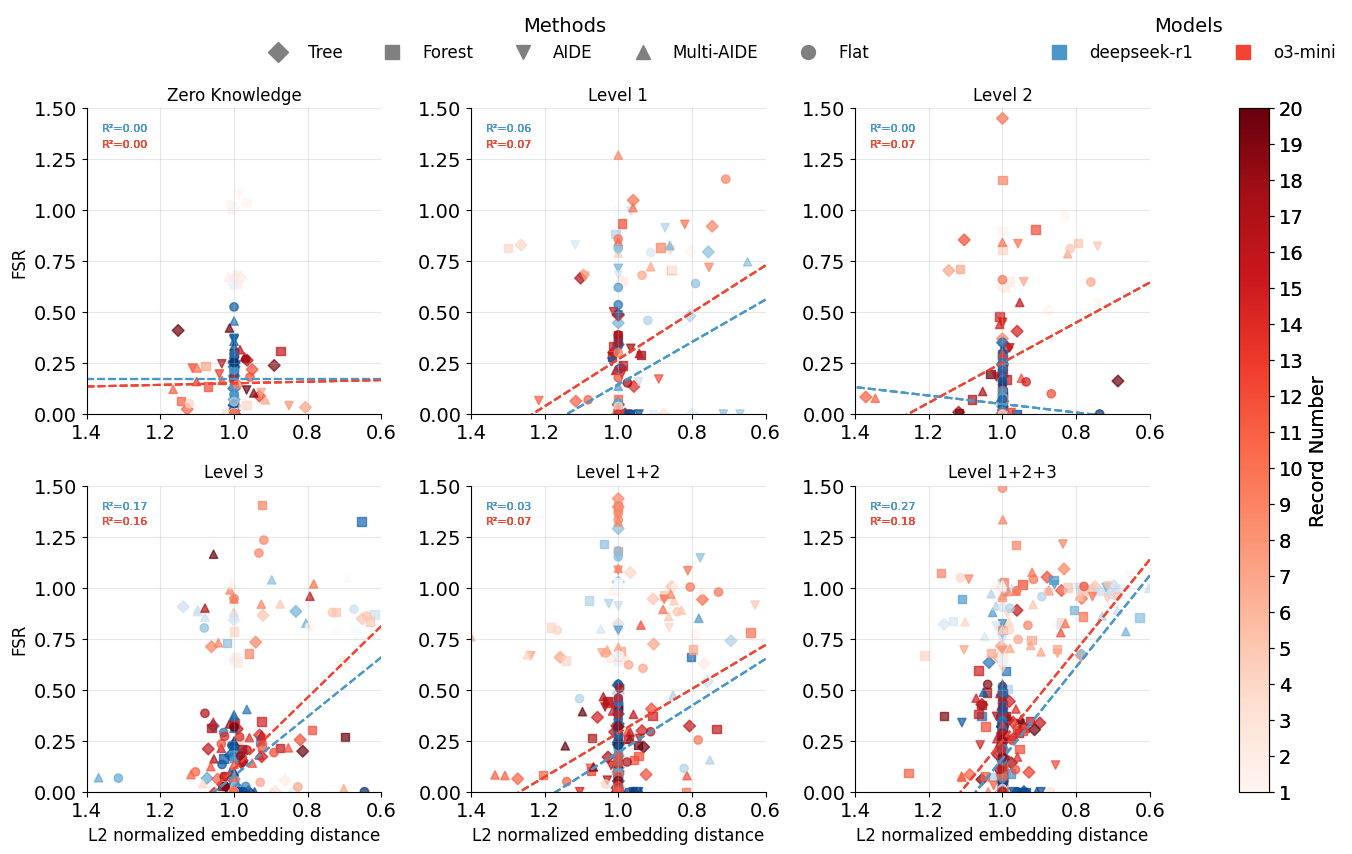

In [102]:
# Get unique methods and models
methods = norm_o3_codes_dist['method'].unique()
models = norm_o3_codes_dist['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}
# fit a line to the points for each model and level pair and compute R^2
model_level_lines = {}
model_level_r2 = {}
model_level_reg = {}

# Get unique levels
levels = norm_o3_codes_dist['levels'].unique()

# For each model-level pair
for model in models:
    model_level_lines[model] = {}
    model_level_r2[model] = {}
    model_level_reg[model] = {}
    for level in levels:
        mask = (norm_o3_codes_dist['model'] == model) & \
               (norm_o3_codes_dist['levels'] == level) #\
                # & (norm_o3_codes_dist['norm_l2_end'] != 1.0)
        x = norm_o3_codes_dist[mask]['norm_l2_end']
        y = norm_o3_codes_dist[mask]['reproduced']
        if len(x) > 0:  # Only fit if we have data points
            # Remove any rows with NaN values
            mask = ~(x.isna() | y.isna())
            x_clean = x[mask]
            y_clean = y[mask]
            
            if len(x_clean) > 0:  # Check we still have data after removing NaNs
                # Reshape x to 2D array required by sklearn
                X = x_clean.values.reshape(-1, 1)
                # Fit linear regression
                reg = LinearRegression().fit(X, y_clean)
                model_level_reg[model][level] = reg
                
                # Create prediction function using sklearn predict
                model_level_lines[model][level] = lambda x: model_level_reg[model][level].predict(x.reshape(-1, 1))
                
                # Calculate R^2 score
                r2 = reg.score(X, y_clean)
                model_level_r2[model][level] = r2

# Create figure and gridspec
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.1])

# Create axes for plots using gridspec
axs = []
for i in range(2):
    for j in range(3):
        ax = fig.add_subplot(gs[i, j])
        axs.append(ax)

# Create colorbar axes
cax = fig.add_subplot(gs[:, -1])

axs = np.array(axs)

# Create a normalizer for record numbers
norm = plt.Normalize(1, 20)  # Record numbers range from 1 to 20

# Plot each level in a separate subplot
for idx, level in enumerate(['z', '1', '2', '5', '12', '125']):
    ax = axs[idx]
    # Plot points for this level
    for method in methods:
        for model in models:
            mask = (norm_o3_codes_dist['method'] == method) & \
                   (norm_o3_codes_dist['model'] == model) & \
                   (norm_o3_codes_dist['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                
                # Get data points for this model/method combination
                x = norm_o3_codes_dist[mask]['norm_l2_end']
                y = norm_o3_codes_dist[mask]['reproduced']
                record_nums = norm_o3_codes_dist[mask]['record']
                
                # Normalize record numbers to [0,1] for color mapping
                norm_records = (record_nums - 1) / 19  # Since records are 1-20
                colors = [cmap(n) for n in norm_records]
                
                # Plot scatter points
                scatter = ax.scatter(x, y, marker=markers[method], c=colors, alpha=0.7)
                
                # Plot fitted lines for each model
                if level in model_level_lines[model]:
                    p = model_level_lines[model][level]
                    r2 = model_level_r2[model][level]
                    
                    # Generate points for line
                    x_line = np.linspace(0.6, 1.4, 100)
                    y_line = p(x_line)
                    
                    # Plot line
                    color = model_cmaps[model](0.6)
                    ax.plot(x_line, y_line, color=color, linestyle='--', alpha=0.7)
                    
                    # Add R² text
                    ax.text(0.05, 0.95 - (list(model_level_r2.keys()).index(model) * 0.05), f'R²={r2:.2f}', 
                        transform=ax.transAxes, fontsize=8,
                        color=color, ha='left', va='top')

    # Customize each subplot
    level_label_mapping = {
        'z': 'Zero Knowledge',
        '1': 'Level 1',
        '2': 'Level 2',
        '5': 'Level 3',
        '12': 'Level 1+2',
        '125': 'Level 1+2+3'
    }
    level_label = level_label_mapping[level]
    ax.set_title(level_label, fontsize=12)
    if idx >= 3:  # Only bottom row gets x labels
        ax.set_xlabel('L2 normalized embedding distance', fontsize=12)
    if idx % 3 == 0:  # Only leftmost column gets y labels
        ax.set_ylabel('FSR', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

# Set common axis limits
for ax in axs:
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.6, 1.4)
    ax.invert_xaxis()

# Create legends
method_map_name = {
    'flat': 'Flat',
    'forest': 'Forest',
    'multi_aide': 'Multi-AIDE',
    'ori_aide': 'AIDE',
    'tree': 'Tree'
}
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method_map_name[method], markersize=10, linestyle='None')
                 for method in methods]

model_patches = [plt.Line2D([0], [0], marker='s', color=model_cmaps[model](0.6),
                          label=model, markersize=10, linestyle='None')
                for model in models]

# Add legends to figure
fig.legend(handles=method_patches, title='Methods',
          bbox_to_anchor=(0.36, 1.08), loc='upper center',
          frameon=False, fontsize=12, ncol=len(method_patches))

fig.legend(handles=model_patches, title='Models',
          bbox_to_anchor=(0.75, 1.08), loc='upper center',
          frameon=False, fontsize=12, ncol=len(model_patches))

# Add two colorbars for each model
cbar_deepseek = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=model_cmaps['deepseek-r1']), 
                            cax=cax, label='Record Number', ticks=range(1, 21))
# cbar_deepseek.set_ticklabels(range(1, 21))
# cbar_deepseek.ax.set_title('deepseek-r1')

# Create a new axis for the second colorbar using gridspec
cax2 = fig.add_subplot(gs[:, -1])
cax2.set_position([cax.get_position().x0 + 0.15, cax.get_position().y0,
                   cax.get_position().width, cax.get_position().height])
cbar_o3 = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=model_cmaps['o3-mini']), 
                       cax=cax2, label='Record Number', ticks=range(1, 21))
cbar_o3.set_ticklabels(range(1, 21))
# cbar_o3.ax.set_title('o3-mini')

plt.tight_layout()
# plt.show()
plt.savefig('figures/FSR_vs_l2_color_code.pdf', dpi=200, bbox_inches='tight')

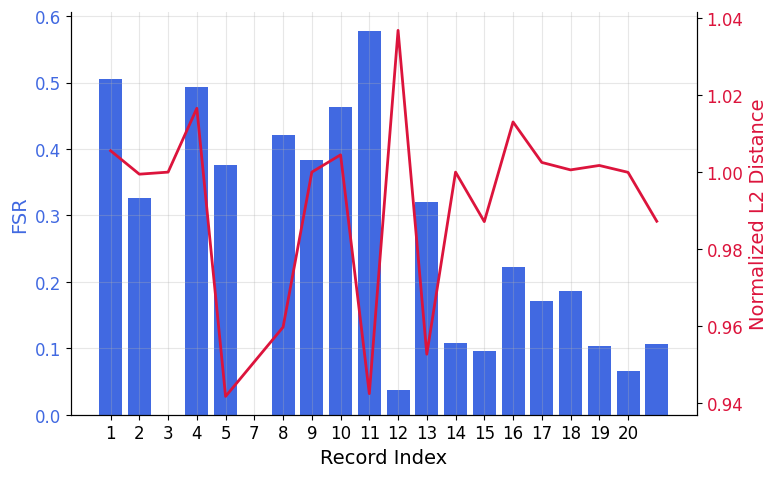

In [140]:
# Filter data for multi_aide, o3-mini, level 2
plot_data = norm_o3_codes_dist[
    (norm_o3_codes_dist.method == 'multi_aide') & 
    (norm_o3_codes_dist.model == 'o3-mini') &
    (norm_o3_codes_dist.levels == '125')
]

# Group by record and take mean
plot_data = plot_data.groupby('record').agg({
    'reproduced': 'mean',
    'norm_l2_end': 'mean'
}).reset_index()

# Drop record 6
plot_data = plot_data[plot_data.record != 6]

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Plot reproduced scores as bars
ax1.bar(plot_data.record, plot_data.reproduced, color='royalblue')
ax1.set_xlabel('Record Index', fontsize=14)
ax1.set_ylabel('FSR', color='royalblue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='royalblue', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)

# Plot norm_l2_end as line
line = ax2.plot(plot_data.record, plot_data.norm_l2_end, color='crimson', linewidth=2)
ax2.set_ylabel('Normalized L2 Distance', color='crimson', fontsize=14)
ax2.tick_params(axis='y', labelcolor='crimson', labelsize=12)

# Set x-axis ticks from 1-19, with labels 1-20 excluding 6
ax1.set_xticks(range(1, 20))
tick_labels = list(range(1, 6)) + list(range(7, 21))
ax1.set_xticklabels(tick_labels)

# Add grid
ax1.grid(True, alpha=0.3)

# Remove top border
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# plt.title('Reproduction Score and Normalized L2 End vs Record Index\nfor Multi-AIDE O3-mini Level 2')
plt.tight_layout()
plt.savefig('figures/FSR_vs_l2_multi_aide_o3_mini_level_2.pdf', dpi=200, bbox_inches='tight')

In [124]:
norm_o3_codes_dist.levels.unique()

array(['z', '1', '2', '5', '12', '125'], dtype=object)

In [86]:
judge_file = '/checkpoint/ram/xianl/projects/nanogpt/scientist/r1_scoring_tree_best_v2.jsonl'
judge_data = []
with open(judge_file, 'r') as f:
    for line in f:
        judge_data.append(json.loads(line))

judge_data[0]

{'method': 'tree',
 'level': '12',
 'record': 'record_14_20250502_121340_2186463-2185781-3',
 'human_metrics': {'job_status': 'COMPLETED',
  'metrics': {'n_steps': 1530, 'val_loss': 3.2739, 'train_time': 273107},
  'hypothesis': 'Baseline run of GPT2 124M model on FineWeb 10B dataset with default hyperparameters.',
  'outcome_summary': 'The model achieves a validation loss of 3.2739 in 4.49 minutes, reaching under the 3.28 target validation loss.'},
 'next_human_metrics': {'job_status': 'COMPLETED',
  'metrics': {'n_steps': 1480, 'val_loss': 3.2771, 'train_time': 241463},
  'hypothesis': 'Baseline run of GPT2 124M model on FineWeb 10B dataset with default hyperparameters.',
  'outcome_summary': 'The model achieves a validation loss of 3.2771 in 4.02 minutes, reaching under the 3.28 target validation loss.'},
 'version': 'v_0',
 'metrics': {'val_loss': 3.2739, 'train_time': 273107},
 'model': 'o3-mini',
 'score_prompt': '\nBelow is a baseline implementation of a GPT-2 model, followed by

In [87]:
remove_think = lambda response: response.split('</think>')[1]

In [88]:
def extract_json_from_string(text: str) -> dict | list | None:
    """
    Extracts a JSON object or array embedded within Markdown code fences
    (specifically ```json ... ```) from a string.

    Args:
        text: The input string potentially containing the JSON in code fences.

    Returns:
        The parsed JSON object (as a dict) or array (as a list),
        or None if no valid JSON block is found or parsing fails.
    """
    # Regex to find content within ```json ... ``` block
    # - ```json : Matches the start fence literally
    # - \s*    : Matches optional whitespace (including newline) after 'json'
    # - (.*?)  : Captures the content non-greedily (*) between fences.
    #            The '.' matches any character, '?' makes it non-greedy.
    # - \s*    : Matches optional whitespace before the end fence
    # - ```    : Matches the end fence literally
    # re.DOTALL flag makes '.' match newline characters as well.
    match = re.search(r'```json\s*(.*?)\s*```', text, re.DOTALL)

    if match:
        json_string = match.group(1).strip() # Extract captured group and strip leading/trailing whitespace
        try:
            # Attempt to parse the extracted string as JSON
            data = json.loads(json_string)
            return data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")
            print(f"Extracted string was: '{json_string}'")
            return None
        except Exception as e:
            print(f"An unexpected error occurred during JSON parsing: {e}")
            return None
    else:
        # print("No ```json ... ``` block found in the string.")
        return None

In [89]:
for data in judge_data:
    item = remove_think(data['r1_response'])
    data['json_res'] = extract_json_from_string(item)

In [90]:
judge_score = {} # record_id -> score
for data in judge_data:
    record_id = data['record']
    if data['json_res'] is None:
        continue
    score = data['json_res']['reproducibility_score']
    judge_score[record_id] = score
len(judge_score)


395

In [91]:
judge_score.keys()

dict_keys(['record_14_20250430_102304_2174598-2158047-3', 'record_8_20250502_004536_2183027-2182665-7', 'record_11_20250430_102304_2174595-2158047-0', 'record_9_20250502_004536_2183028-2182665-8', 'record_16_20250502_121340_2186465-2185781-5', 'record_12_20250429_084908_2142693-2142657-1', 'record_13_20250502_121340_2186462-2185781-2', 'record_1_20250429_084906_2142683-2142655-0', 'record_17_20250430_102304_2174601-2158047-6', 'record_3_20250502_004536_2183022-2182665-2', 'record_4_20250429_084906_2142686-2142655-3', 'record_11_20250502_121340_2186460-2185781-0', 'record_18_20250430_102304_2158047-2158047-7', 'record_19_20250503_001406_2193732-2191457-0', 'record_18_20250429_084908_2142657-2142657-7', 'record_11_20250429_084908_2142692-2142657-0', 'record_9_20250429_084906_2142691-2142655-8', 'record_7_20250502_004536_2183026-2182665-6', 'record_2_20250502_004536_2183021-2182665-1', 'record_15_20250502_121340_2186464-2185781-4', 'record_15_20250430_102304_2174599-2158047-4', 'record_20

In [92]:
from collections import defaultdict

In [93]:
new_df = defaultdict(list)
for idx, row in norm_o3_codes_dist.iterrows():
    if row['run_id'] not in judge_score:
        continue
    # Skip if judge_score is 1.0 or reproduced is 0.0
    if judge_score[row['run_id']] == 1.0 or row['reproduced'] == 0.0:
        continue
    new_df['run_id'].append(row['run_id'])
    new_df['record'].append(row['record'])
    new_df['method'].append(row['method'])
    new_df['levels'].append(row['levels'])
    new_df['model'].append(row['model'])
    new_df['reproduced'].append(row['reproduced'])
    new_df['norm_l2_end'].append(row['norm_l2_end'])
    new_df['judge_score'].append(judge_score[row['run_id']])
    new_df['l2_end'].append(row['l2_end'])

In [94]:
new_df = pd.DataFrame(new_df)

In [95]:
new_df.head()

,run_id,record,method,levels,model,reproduced,norm_l2_end,judge_score,l2_end
0,record_16_20250502_121340_2186465-2185781-5,16,tree,12,o3-mini,0.322458,0.806343,0.25,23.964155
1,record_12_20250429_084908_2142693-2142657-1,12,tree,12,o3-mini,0.084219,0.924392,0.00,15.808537
2,record_1_20250429_084906_2142683-2142655-0,1,tree,12,o3-mini,0.985058,1.000000,0.50,23.560734
3,record_4_20250429_084906_2142686-2142655-3,4,tree,12,o3-mini,0.822885,1.000000,0.71,14.193036
4,record_11_20250429_084908_2142692-2142657-0,11,tree,12,o3-mini,0.063030,1.272970,0.20,21.871080


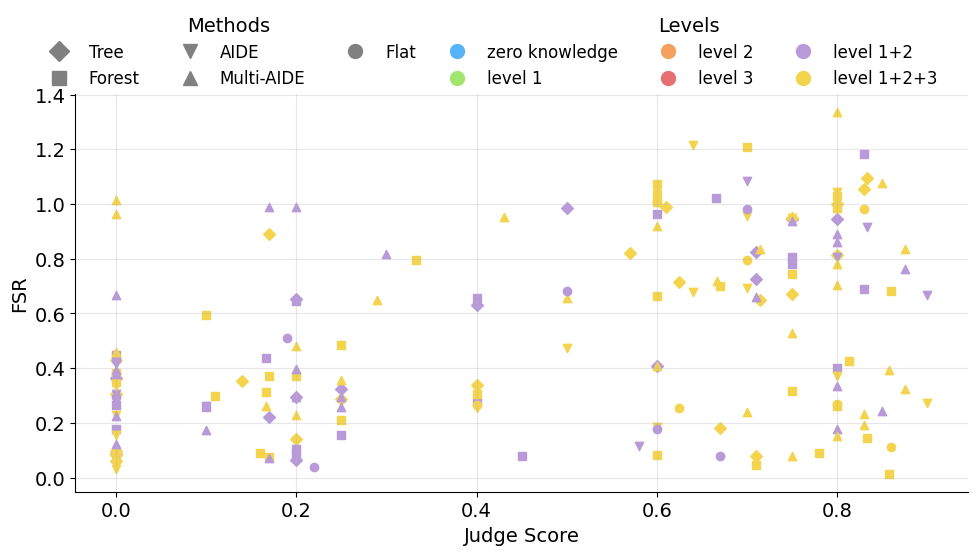

In [113]:
# Get unique methods and models
methods = new_df['method'].unique()
models = new_df['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colors for levels
colors = ['#56B3FA', '#A0E56D', '#F3A15D', '#E76F6F', '#B99AD9', '#F4D44D']
color_mapping = {'z': colors[0], '1': colors[1], '2': colors[2], '5': colors[3], '12': colors[4], '125': colors[5]}

fig, ax = plt.subplots(figsize=(10, 5))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (new_df['method'] == method) & \
                   (new_df['model'] == model) & \
                   (new_df['levels'] == level)
            
            if mask.any():
                color = color_mapping[level]
                ax.scatter(
                        new_df[mask]['judge_score'], 
                        new_df[mask]['reproduced'],
                        marker=markers[method],
                        c=color,)
                        # alpha=1.0)

ax.set_xlabel('Judge Score', fontsize=14)
ax.set_ylabel('FSR', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)

# Create legend for methods
method_map_name = {
    'flat': 'Flat',
    'forest': 'Forest',
    'multi_aide': 'Multi-AIDE',
    'ori_aide': 'AIDE',
    'tree': 'Tree'
}
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method_map_name[method], markersize=10, linestyle='None')
                 for method in methods]

level_patches = []
level_labels = []
level_labels_map = {
    'z': 'zero knowledge',
    '1': 'level 1',
    '2': 'level 2',
    '5': 'level 3',
    '12': 'level 1+2',
    '125': 'level 1+2+3'
}

for level in ['z', '1', '2', '5', '12', '125']:
    label = level_labels_map[level]
    color = color_mapping[level]
    marker = plt.Line2D([0], [0], marker='o', color=color, markerfacecolor=color, markersize=10, linestyle='None')
    level_patches.append(marker)
    level_labels.append(label)

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.24, 1.13), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

fig.legend(level_patches, level_labels, title='Levels',
           bbox_to_anchor=(0.7, 1.13), loc='upper center',
           ncol=len(level_patches)//2, frameon=False, fontsize=12)

plt.tight_layout()
plt.savefig('figures/FSR_vs_judge.pdf', dpi=200, bbox_inches='tight')

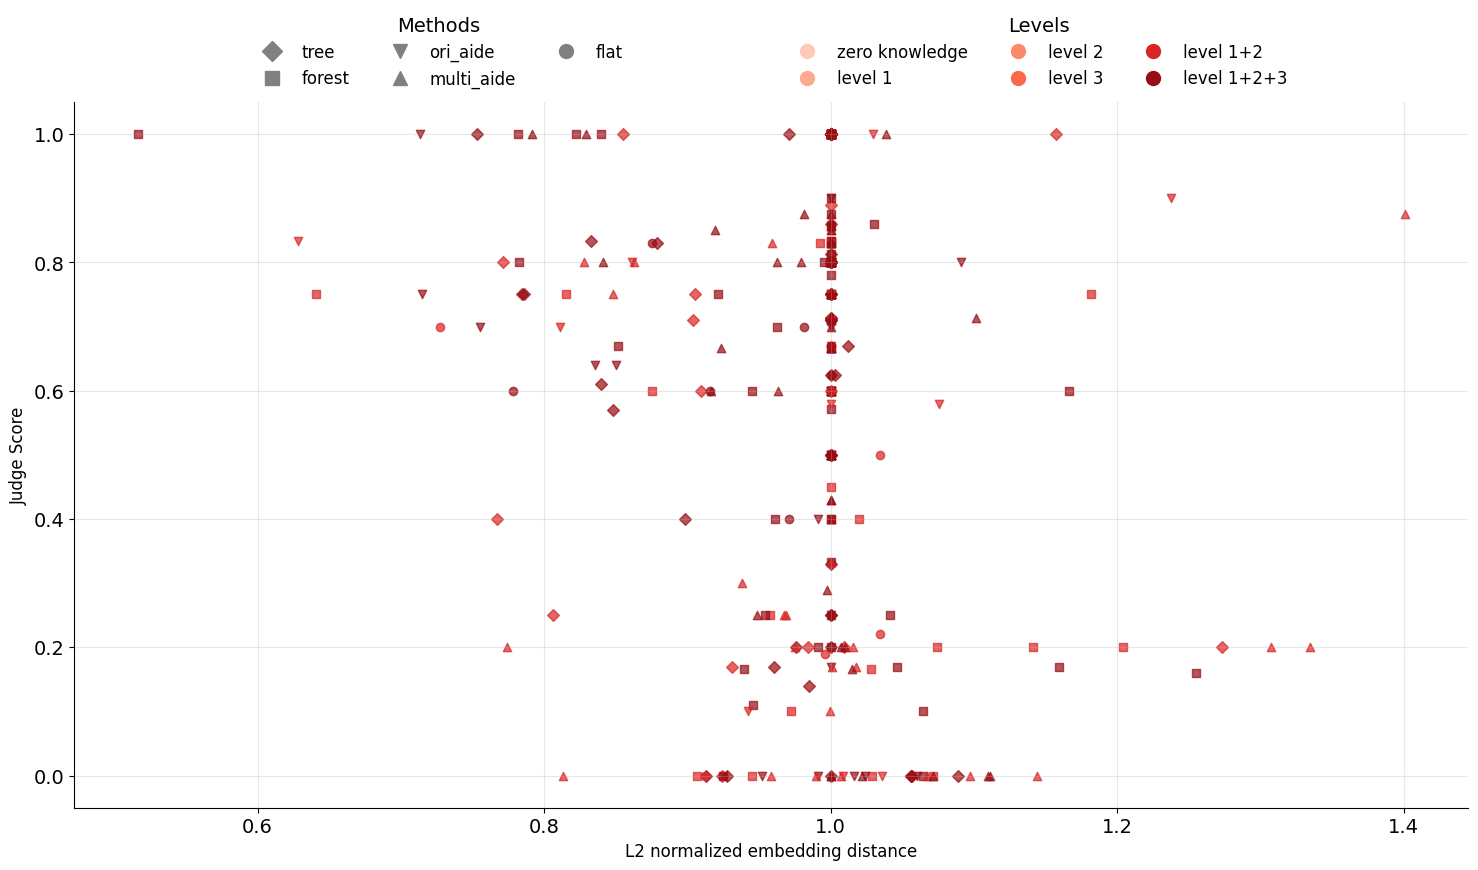

In [47]:
# Get unique methods and models
methods = new_df['method'].unique()
models = new_df['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Define level darkness scale (0 to 1)
level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

fig, ax = plt.subplots(figsize=(15, 8))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (new_df['method'] == method) & \
                   (new_df['model'] == model) & \
                   (new_df['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(level_darkness[level])
                ax.scatter(
                         new_df[mask]['norm_l2_end'],
                         new_df[mask]['judge_score'], 
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

ax.set_ylabel('Judge Score', fontsize=12)
ax.set_xlabel('L2 normalized embedding distance', fontsize=12)
# ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)
# ax.invert_yaxis()

# Create legend for methods
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

# Create legend for models and levels 
model_patches = []
for model in models:
    cmap = model_cmaps[model]
    model_patches.append(
        plt.Line2D([0], [0], marker='s', color=cmap(0.5),
                   label=model, markersize=10, linestyle='None')
    )

level_patches = []
level_labels = []
for level in ['z', '1', '2', '5', '12', '125']:
    label = level_labels_map[level]
    color1 = model_cmaps['o3-mini'](level_darkness[level])
    # color2 = model_cmaps['deepseek-r1'](level_darkness[level])

    marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
    # marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
    # level_patches.append((marker_1, marker_2))
    level_patches.append(marker_1)
    level_labels.append(label)
    # level_patches.append(
    #     plt.Line2D([0], [0], marker='o', color=color,
    #                 label=label, markersize=10, linestyle='None')
    # )

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.3, 1.10), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

# fig.legend(handles=model_patches, title='Models',
#            bbox_to_anchor=(0.5, 1.10), loc='upper center',
#            ncol=len(model_patches), frameon=False, fontsize=12)

fig.legend(level_patches, level_labels, title='Levels',
           bbox_to_anchor=(0.7, 1.10), loc='upper center',
           ncol=len(level_patches)//2, frameon=False, fontsize=12)
# fig.legend(level_patches, level_labels, title='Levels',
#            handler_map={tuple: HandlerTuple(ndivide=None)},
#            loc='upper center', bbox_to_anchor=(0.8, 1.10),
#            ncol=len(level_patches)//2, frameon=False)

plt.tight_layout()
plt.show()